In [1]:
import mg5qs_import as qs
from pathlib import Path 

In [2]:
LHE = Path('/home/leo/MadStats/mg5qs/output/cledq__3332_SM_small/Events/run_01/unweighted_events.lhe')
result, four_momenta, status = qs.generate_vals(15, LHE)


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.311      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change:  8 Mar 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 19 Feb 2025 at 11:33:15    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

In [3]:
import pandas as pd
import numpy as np

In [4]:
df_stat = pd.DataFrame(status, columns = result['fields'].split(','))
df_mom = pd.DataFrame(four_momenta, columns=['px','py','pz','E'])
df_mom['pT'] = np.sqrt((df_mom['px']**2)+(df_mom['py']**2))
df = pd.concat([df_stat, df_mom], axis=1)
df

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
0,1,232,-23,0,1,172,0,-24,90,234,...,15,22,1,1,0,-34.889793,28.070758,-12.855458,46.622802,44.780187
1,1,234,-51,0,1,232,0,15,90,454,...,16,-14,0,1,1,-34.889793,28.070758,-12.855457,46.622801,44.780186
2,2,314,-23,0,1,244,0,-24,90,603,...,16,-211,0,1,0,3.293480,-12.296104,-18.687036,22.680482,12.729540
3,3,491,-23,0,1,364,0,-24,90,888,...,16,-311,0,1,0,-10.970048,-22.105751,-39.339498,46.473219,24.678051
4,4,1098,-23,0,1,830,0,-24,90,1100,...,15,22,1,1,0,2.315831,-36.273324,7.630251,37.181925,36.347175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14243,9998,297,-23,0,1,224,0,-24,90,299,...,15,22,1,1,0,-6.738243,12.305188,-5.871966,15.312063,14.029311
14244,9998,299,-51,0,1,297,0,15,90,608,...,16,211,0,1,1,-6.738243,12.305188,-5.871966,15.312064,14.029312
14245,9999,158,-23,0,1,117,0,-24,90,160,...,15,22,1,1,0,-15.832486,41.759548,-72.751881,85.384550,44.660132
14246,9999,160,-51,0,1,158,0,15,90,307,...,16,-12,0,1,1,-15.832305,41.759326,-72.751695,85.384250,44.659861


In [50]:
df[df['EVENT']==df[df['CHAININDEX']==df['CHAININDEX'].max()]['EVENT'].iloc[0]] # find the event with the longest chain

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
6707,4705,5,-23,0,1,3,4,1,-2,9,...,15,15,1,1,0,9.127158,-18.454671,-14.697021,25.358235,20.588344
6708,4705,9,-44,0,1,5,5,15,15,14,...,15,15,1,1,1,-11.569576,-16.520634,-43.377653,47.870293,20.168948
6709,4705,14,-44,0,1,9,9,15,15,20,...,15,15,1,1,2,-10.431024,-12.502999,-21.514626,27.040120,16.282851
6710,4705,20,-44,0,1,14,14,15,15,27,...,15,15,1,1,3,-9.847825,-11.480222,-17.110899,22.906675,15.125315
6711,4705,27,-44,0,1,20,20,15,15,35,...,15,15,1,1,4,-10.259917,-11.488610,-17.752323,23.570251,15.403053
6712,4705,35,-44,0,1,27,27,15,15,93,...,15,15,1,1,5,-10.272059,-11.568007,-17.902853,23.727702,15.470423
6713,4705,93,-44,0,1,35,35,15,15,121,...,15,15,1,1,6,-10.252138,-11.580949,-17.884652,23.711668,15.466891
6714,4705,121,-44,0,1,93,93,15,15,253,...,15,15,1,1,7,-10.265347,-11.591343,-17.926486,23.754015,15.483430
6715,4705,253,-44,0,1,121,121,15,15,287,...,15,15,1,1,8,-10.269504,-11.593589,-17.937804,23.765449,15.487867
6716,4705,287,-44,0,1,253,253,15,15,494,...,15,15,1,1,9,-10.180834,-11.823441,-17.895694,23.808754,15.602665


As a first try, we can simpely compare the beggining of a chain to its end and see which has larger pT. We know (by construction) that the end of the chain will always have DUPLICATED=0. Simularly, the beggining element will always have a chain index of 0. So our condations are if not duplicated **or** not chainindex (i.e. ==0).

In [55]:
df_begend = df[np.logical_xor(df['CHAININDEX']==0, df['DUPLICATED']==0)]
df_begend

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
0,1,232,-23,0,1,172,0,-24,90,234,...,15,22,1,1,0,-34.889793,28.070758,-12.855458,46.622802,44.780187
1,1,234,-51,0,1,232,0,15,90,454,...,16,-14,0,1,1,-34.889793,28.070758,-12.855457,46.622801,44.780186
4,4,1098,-23,0,1,830,0,-24,90,1100,...,15,22,1,1,0,2.315831,-36.273324,7.630251,37.181925,36.347175
5,4,1100,-51,0,1,1098,0,15,90,1882,...,16,211,0,1,1,2.285179,-35.834478,7.534274,36.732205,35.907268
8,7,1031,-23,0,1,767,0,-24,90,1033,...,15,22,1,1,0,29.917059,9.089232,50.624216,59.528258,31.267308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14242,9997,566,-51,0,1,564,0,15,90,1023,...,16,211,0,1,1,-35.461933,17.956612,-24.246226,46.594268,39.749070
14243,9998,297,-23,0,1,224,0,-24,90,299,...,15,22,1,1,0,-6.738243,12.305188,-5.871966,15.312063,14.029311
14244,9998,299,-51,0,1,297,0,15,90,608,...,16,211,0,1,1,-6.738243,12.305188,-5.871966,15.312064,14.029312
14245,9999,158,-23,0,1,117,0,-24,90,160,...,15,22,1,1,0,-15.832486,41.759548,-72.751881,85.384550,44.660132


Itterating through the data frame could be elimated by encoding the pT of the first partent of each particle on the C++ side, but this would overspecilize that routine to this particular task. I have chosen to leave that general at the expence of the effishance of this inquary.

In [75]:
chains = {}
for i,r in df_begend.iterrows():
    key = (int(r['EVENT']), int(r['CHAIN']))
    if key not in chains:
        chains[key] = []
    chains[key].append(r['pT']) # the physics is causal, so we can always depend on the order being [pT_first, pT_last]

In [80]:
begend = np.zeros((len(chains), 2))
for i,v in enumerate(chains.values()):
    begend[i] = v

In [85]:
sum(begend[:,1]/begend[:,0]>1)/begend.shape[0] # number of times pT increaced (proporation)

np.float64(0.04908835904628331)

In [86]:
import matplotlib.pyplot as plt

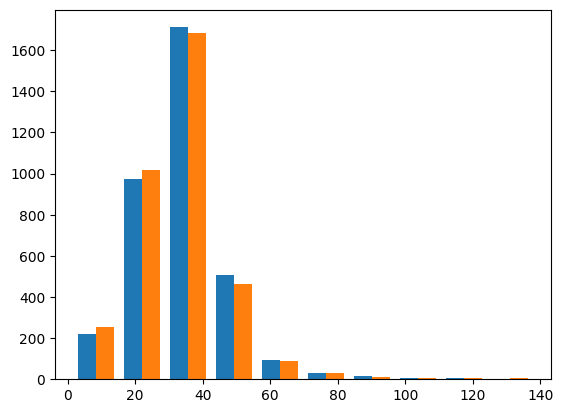

In [89]:
plt.hist(begend)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

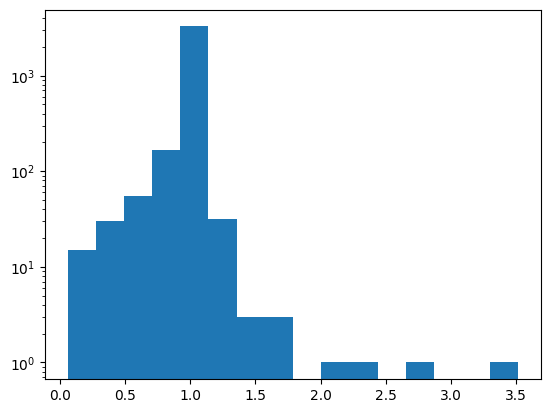

In [103]:
plt.hist(begend[:,1]/begend[:,0], bins=16)
plt.yscale('log')
plt.show

In [109]:
np.sum(np.abs(1-(begend[:,1]/begend[:,0]))>0.05)/begend.shape[0] # percent of events for which init and final pT is within 5% of origtional

np.float64(0.10855539971949509)

This all begs the question, what if we normalize by change in magnatude of p? But this is the same as asking how the azimuthal angle will change. So lets compute that and take a look.

In [117]:
df_begend = df_begend.copy()
df_begend['azimuthal_angle'] = np.arctan2(df_begend['py'], df_begend['px'])

In [118]:
df_begend 

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT,azimuthal_angle
0,1,232,-23,0,1,172,0,-24,90,234,...,22,1,1,0,-34.889793,28.070758,-12.855458,46.622802,44.780187,2.464080
1,1,234,-51,0,1,232,0,15,90,454,...,-14,0,1,1,-34.889793,28.070758,-12.855457,46.622801,44.780186,2.464080
4,4,1098,-23,0,1,830,0,-24,90,1100,...,22,1,1,0,2.315831,-36.273324,7.630251,37.181925,36.347175,-1.507039
5,4,1100,-51,0,1,1098,0,15,90,1882,...,211,0,1,1,2.285179,-35.834478,7.534274,36.732205,35.907268,-1.507112
8,7,1031,-23,0,1,767,0,-24,90,1033,...,22,1,1,0,29.917059,9.089232,50.624216,59.528258,31.267308,0.294953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14242,9997,566,-51,0,1,564,0,15,90,1023,...,211,0,1,1,-35.461933,17.956612,-24.246226,46.594268,39.749070,2.672868
14243,9998,297,-23,0,1,224,0,-24,90,299,...,22,1,1,0,-6.738243,12.305188,-5.871966,15.312063,14.029311,2.071790
14244,9998,299,-51,0,1,297,0,15,90,608,...,211,0,1,1,-6.738243,12.305188,-5.871966,15.312064,14.029312,2.071790
14245,9999,158,-23,0,1,117,0,-24,90,160,...,22,1,1,0,-15.832486,41.759548,-72.751881,85.384550,44.660132,1.933187


In [131]:
chains_ang = {}
for i,r in df_begend.iterrows():
    key = (int(r['EVENT']), int(r['CHAIN']))
    if key not in chains_ang:
        chains_ang[key] = []
    chains_ang[key].append(r['azimuthal_angle']) 
    
phi_begend = np.zeros((len(chains_ang), 2))
for i,v in enumerate(chains_ang.values()):
    phi_begend[i] = v

phi_begend

array([[ 2.46408042,  2.46408043],
       [-1.50703894, -1.50711215],
       [ 0.29495253,  0.29495253],
       ...,
       [ 2.67286759,  2.67286759],
       [ 2.0717902 ,  2.07179018],
       [ 1.93318685,  1.9331848 ]])

In [132]:
max(np.abs(phi_begend[:,0]-phi_begend[:,1])) # this leaves begind some wrapping errors (2pi->0)

np.float64(6.281824491374604)

In [133]:
a=np.abs(phi_begend[:,0]-phi_begend[:,1])
b=np.abs(np.abs(phi_begend[:,0]-phi_begend[:,1])-(2*np.pi))
deltaphi = np.minimum(a,b)

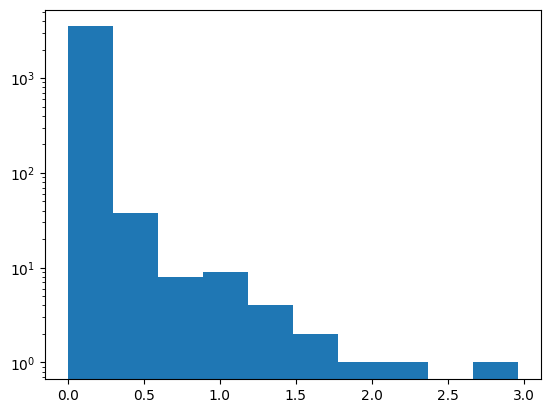

In [136]:
plt.hist(deltaphi)
plt.yscale('log')
plt.show()

The diffrence in azimuthal angle may be misleading because vectors far from the beam axis which switch axtross the transverse plane will have an inflated change in angle. We can adress this by asking about the diffrence of overall direction, but this comes at the expence of no longer being usefull for making statments about if the vector became more or less transverse. It could however be usefull in understanding if this line of inquary is even valid. Afterall, if the angle changes are very small, then there is less foundation on which to find preferance in direction. 

Yet again, we will pull out the data, this time preserving all three components of momentum.

In [219]:
chains_dir = {}
for i,r in df_begend.iterrows():
    key = (int(r['EVENT']), int(r['CHAIN']))
    if key not in chains_dir:
        chains_dir[key] = []
    chains_dir[key].append((r['px'], r['py'], r['pz'])) 

dir_begend = np.zeros((len(chains_dir), 2, 3))
for i,v in enumerate(chains_dir.values()):
    dir_begend[i] = v

dot = np.einsum('ij,ij->i', dir_begend[:, 0, :], dir_begend[:, 1, :])
norms = np.linalg.norm(dir_begend[:, 0, :], axis=1) * np.linalg.norm(dir_begend[:, 1, :], axis=1)
cos_theta = np.clip(dot/norms, -1, 1) # due to fpe the results may slightly exceed bounds 
delta_theta = np.arccos(cos_theta)

In [220]:
delta_theta.min(), delta_theta.max() 

(np.float64(0.0), np.float64(1.994403125023134))

So, sometimes the approxamations eliminate direction change entierly, and other times the particle reverses direction entierly. 

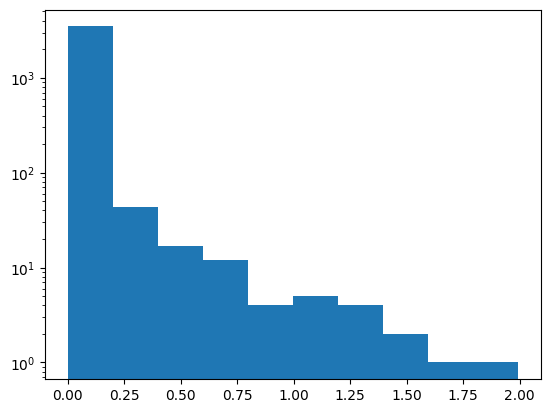

In [222]:
plt.hist(delta_theta)
plt.yscale('log')
plt.show()

Most of the time, the change is marginal. Lets try to find the event which has the largest change in direction.

In [242]:
df[df['EVENT']==df_begend.iloc[np.argmax(delta_theta)*2]['EVENT'].astype(int)]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
5342,3736,5,-23,0,1,3,4,-2,1,9,...,15,15,1,1,0,-9.013020,32.526636,-2.048119,33.861026,33.752283
5343,3736,9,-44,0,1,5,5,15,15,14,...,15,15,1,1,1,14.229804,4.511641,-17.485602,23.059624,14.927901
5344,3736,14,-44,0,1,9,9,15,15,20,...,15,15,1,1,2,5.472887,-17.502007,-17.261499,25.246581,18.337741
5345,3736,20,-44,0,1,14,14,15,15,34,...,15,15,1,1,3,4.558055,-9.875613,-20.063115,22.890826,10.876746
5346,3736,34,-44,0,1,20,20,15,15,43,...,15,15,1,1,4,4.558233,-9.857987,-19.976083,22.806995,10.860820
5347,3736,43,-44,0,1,34,34,15,15,85,...,15,15,1,1,5,4.543484,-9.865089,-19.975018,22.806190,10.861088
5348,3736,85,-44,0,1,43,43,15,15,256,...,15,15,1,1,6,4.595580,-9.748283,-19.997174,22.785809,10.777215
5349,3736,256,-44,0,1,85,85,15,15,448,...,15,15,1,1,7,4.626380,-9.734453,-19.997024,22.785997,10.777892
5350,3736,448,-62,0,1,256,256,15,15,1156,...,16,-211,0,1,8,4.629745,-9.680498,-20.011640,22.776524,10.730637
